# Energy Prices — Exploratory Analysis

## Objective
Characterise the NORD day-ahead price series that the capture-rate model is
fit on: level and trend, distribution, seasonality, intraday shape, volatility,
spike frequency, and the NORD-PUN zonal spread. Each chart states what to look
for and what it shows.

## Pipeline Position

| Inputs | This notebook | Outputs |
|---|---|---|
| `Data/Cleaned/df_energy_cleaned.parquet` | Exploratory analysis | `Data/Results/GME_NORD_annual_summary.csv` |

## Setup

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root() -> Path:
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "Code").is_dir() and (cand / "Data").is_dir():
            return cand
    raise RuntimeError(f"Project root not found above {here}")


ROOT = find_project_root()
INPUT_PATH  = ROOT / "Data" / "Cleaned" / "df_energy_cleaned.parquet"
RESULTS_DIR = ROOT / "Data" / "Results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9,
})

MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]


## Load Data

In [2]:
df = pd.read_parquet(INPUT_PATH)
df["datetime_local"] = pd.to_datetime(df["datetime_local"])
df["year"]       = df["datetime_local"].dt.year
df["month"]      = df["datetime_local"].dt.month
df["weekday"]    = df["datetime_local"].dt.dayofweek     # 0=Mon, 6=Sun
df["is_weekend"] = df["weekday"].isin([5, 6])

print(f"Shape      : {df.shape}")
print(f"Date range : {df['datetime_local'].min()}  ->  {df['datetime_local'].max()}")
print(f"Zero-flagged (kept, real)   : {int(df['zero_flag'].sum() - df['imputed_flag'].sum())}")
print(f"Imputed (short gaps)        : {int(df['imputed_flag'].sum())}")
print(f"Spike / extreme hours       : {int((df['price_flag'] > 0).sum())}  ({(df['price_flag'] > 0).mean():.2%})")
df["price_NORD_EURMWh"].describe().round(2)

Shape      : (186024, 14)
Date range : 2005-01-01 00:00:00+01:00  ->  2026-03-22 23:00:00+01:00
Zero-flagged (kept, real)   : 19
Imputed (short gaps)        : 14
Spike / extreme hours       : 9713  (5.22%)


count    186024.00
mean         83.59
std          69.81
min           0.00
25%          47.70
50%          65.00
75%          95.00
max         871.00
Name: price_NORD_EURMWh, dtype: float64

## Level & Trend

**What to look for:** the long-run price level, and whether the 2022 energy
crisis is a step-change or a spike that reverts.

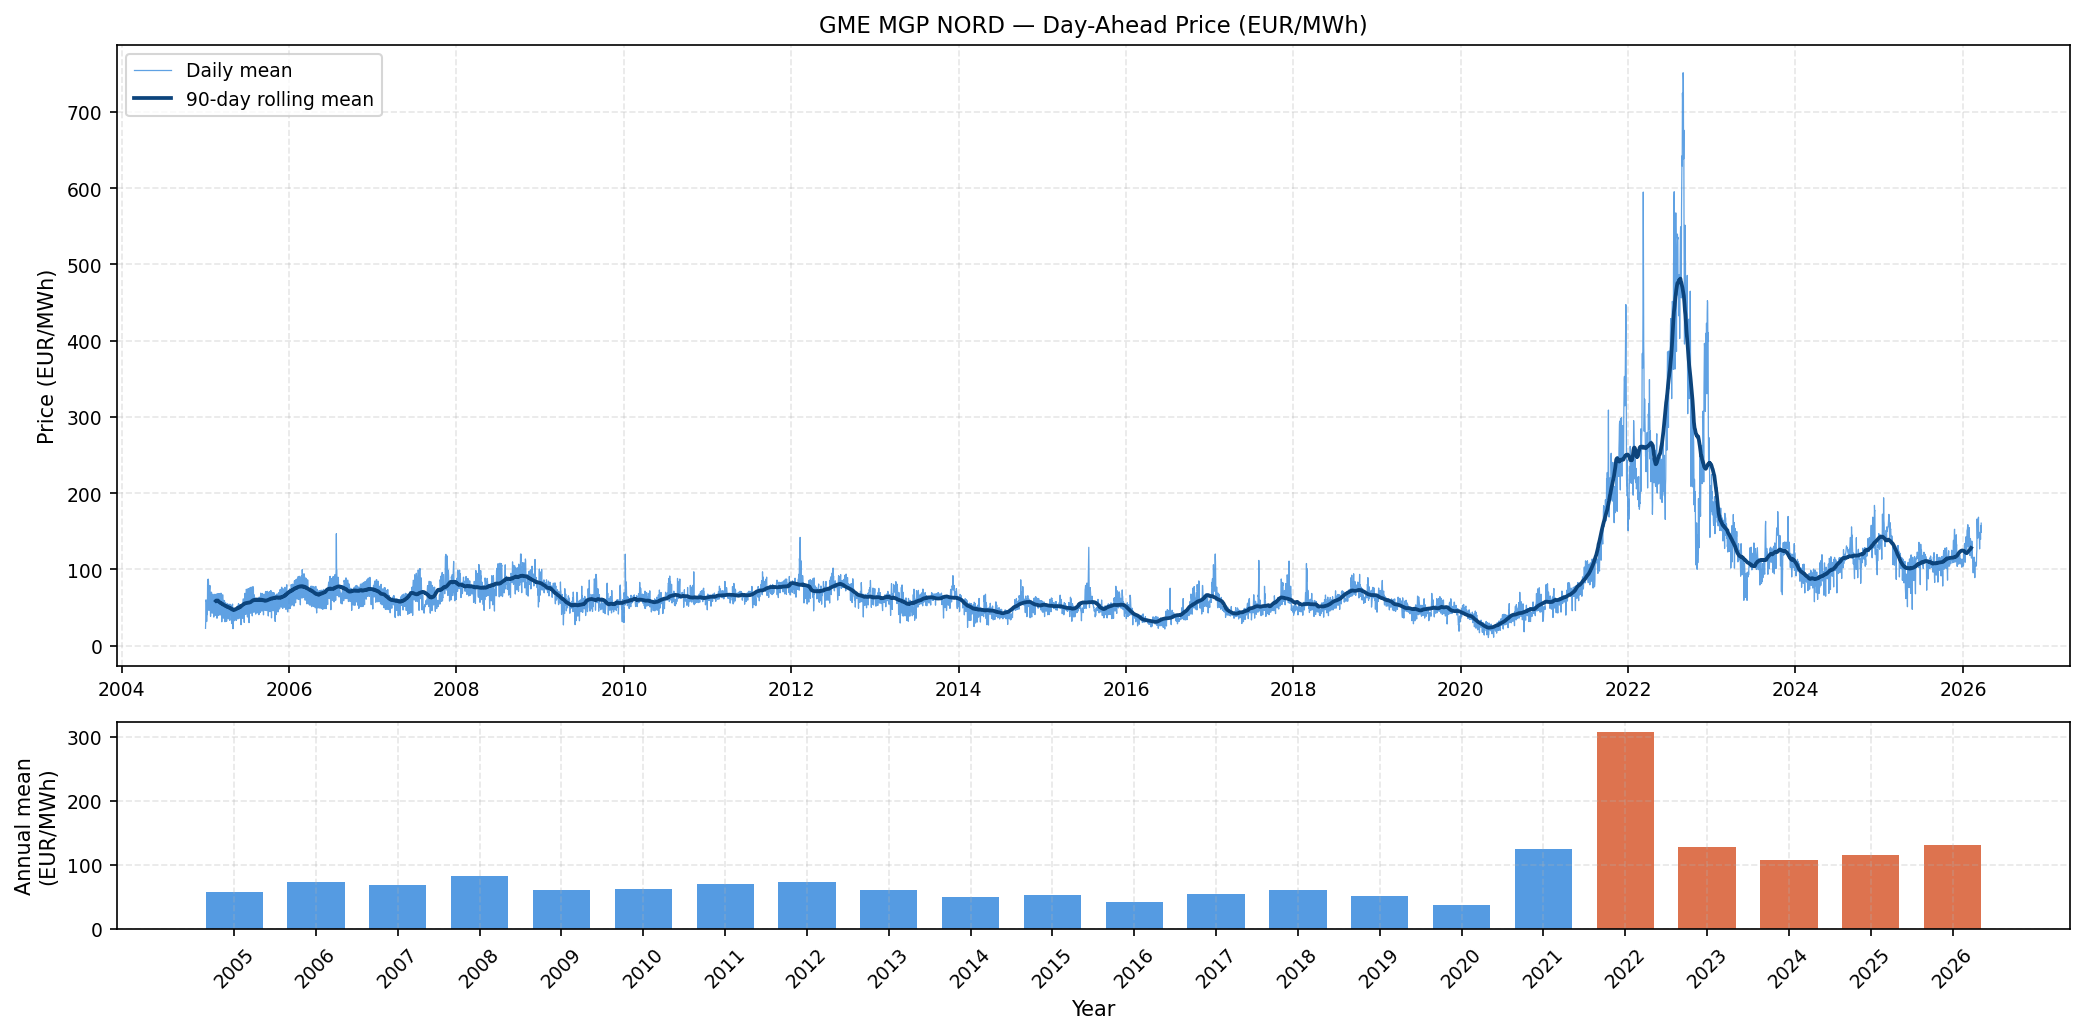

[SAVED] fig_energy_01_level_trend.png / .pdf


In [3]:
df_daily  = df.groupby("date")["price_NORD_EURMWh"].mean().reset_index()
df_daily["date"] = pd.to_datetime(df_daily["date"])
df_annual = df.groupby("year")["price_NORD_EURMWh"].mean().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={"height_ratios": [3, 1]})

ax = axes[0]
ax.plot(df_daily["date"], df_daily["price_NORD_EURMWh"], color="#378ADD", linewidth=0.6, alpha=0.8, label="Daily mean")
roll = df_daily.set_index("date")["price_NORD_EURMWh"].rolling(90, center=True).mean()
ax.plot(roll.index, roll.values, color="#0C447C", linewidth=1.8, label="90-day rolling mean")
ax.set_title("GME MGP NORD — Day-Ahead Price (EUR/MWh)", fontweight="500")
ax.set_ylabel("Price (EUR/MWh)")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left")

ax = axes[1]
colors = ["#378ADD" if y < 2022 else "#D85A30" for y in df_annual["year"]]
ax.bar(df_annual["year"], df_annual["price_NORD_EURMWh"], color=colors, width=0.7, alpha=0.85)
ax.set_ylabel("Annual mean\n(EUR/MWh)")
ax.set_xlabel("Year")
ax.set_xticks(df_annual["year"])
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


> **Takeaway.** Prices are flat around 40-60 EUR/MWh for most of the sample and
> spike sharply from 2021, staying elevated through 2022-2023 (red bars) before
> partially reverting — a regime shift the capture-rate model needs to
> condition on, not average away.

## Distribution

**What to look for:** how fat the right tail is, and whether the 2022 crisis
year is a distinct regime in the year-by-year box plot.

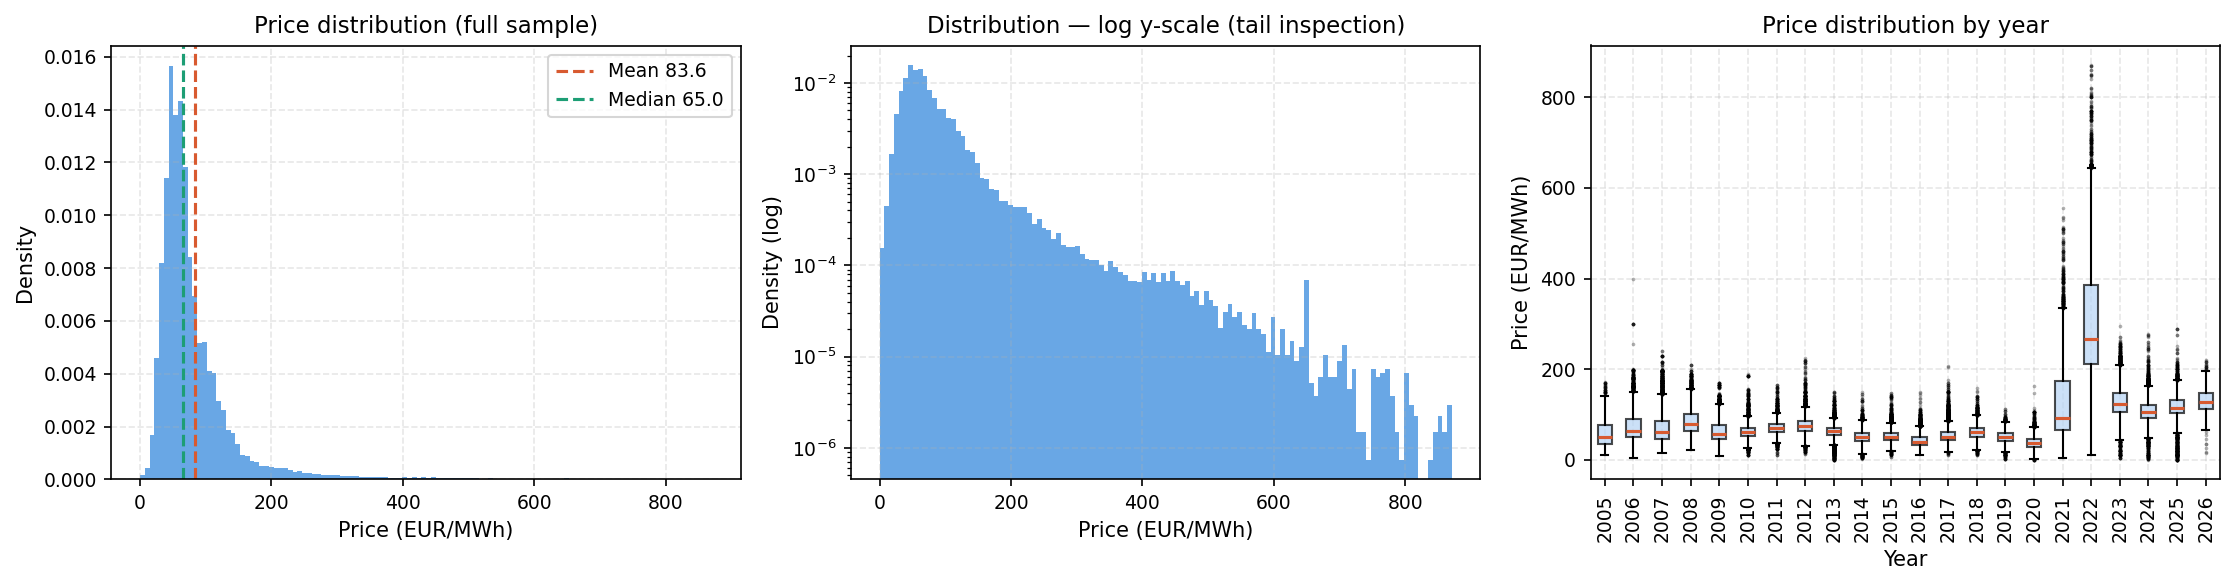

[SAVED] fig_energy_02_distribution.png / .pdf


In [4]:
price = df["price_NORD_EURMWh"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.hist(price, bins=120, color="#378ADD", alpha=0.75, edgecolor="none", density=True)
ax.axvline(price.mean(),   color="#D85A30", linewidth=1.5, linestyle="--", label=f"Mean {price.mean():.1f}")
ax.axvline(price.median(), color="#1D9E75", linewidth=1.5, linestyle="--", label=f"Median {price.median():.1f}")
ax.set_title("Price distribution (full sample)")
ax.set_xlabel("Price (EUR/MWh)"); ax.set_ylabel("Density"); ax.legend()

ax = axes[1]
ax.hist(price.clip(lower=0.01), bins=120, color="#378ADD", alpha=0.75, edgecolor="none", density=True, log=True)
ax.set_title("Distribution — log y-scale (tail inspection)")
ax.set_xlabel("Price (EUR/MWh)"); ax.set_ylabel("Density (log)")

ax = axes[2]
years = sorted(df["year"].unique())
data_list = [df.loc[df["year"] == y, "price_NORD_EURMWh"].dropna().values for y in years]
ax.boxplot(data_list, tick_labels=years, patch_artist=True,
           medianprops={"color": "#D85A30", "linewidth": 1.5},
           flierprops={"marker": ".", "markersize": 1.5, "alpha": 0.3},
           boxprops={"facecolor": "#B5D4F4", "alpha": 0.7})
ax.set_title("Price distribution by year")
ax.set_xlabel("Year"); ax.set_ylabel("Price (EUR/MWh)")
ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


> **Takeaway.** The distribution is right-skewed with a long tail even on a
> log scale, motivating a log-price transform for modelling. 2022's box sits
> far above every other year, confirming the crisis is a genuine regime
> rather than a handful of outlier hours.

## Seasonality Heatmaps

**What to look for:** the year-over-year trend (left) and the emergence of a
midday price dip (right) — the visual signature of solar cannibalisation.

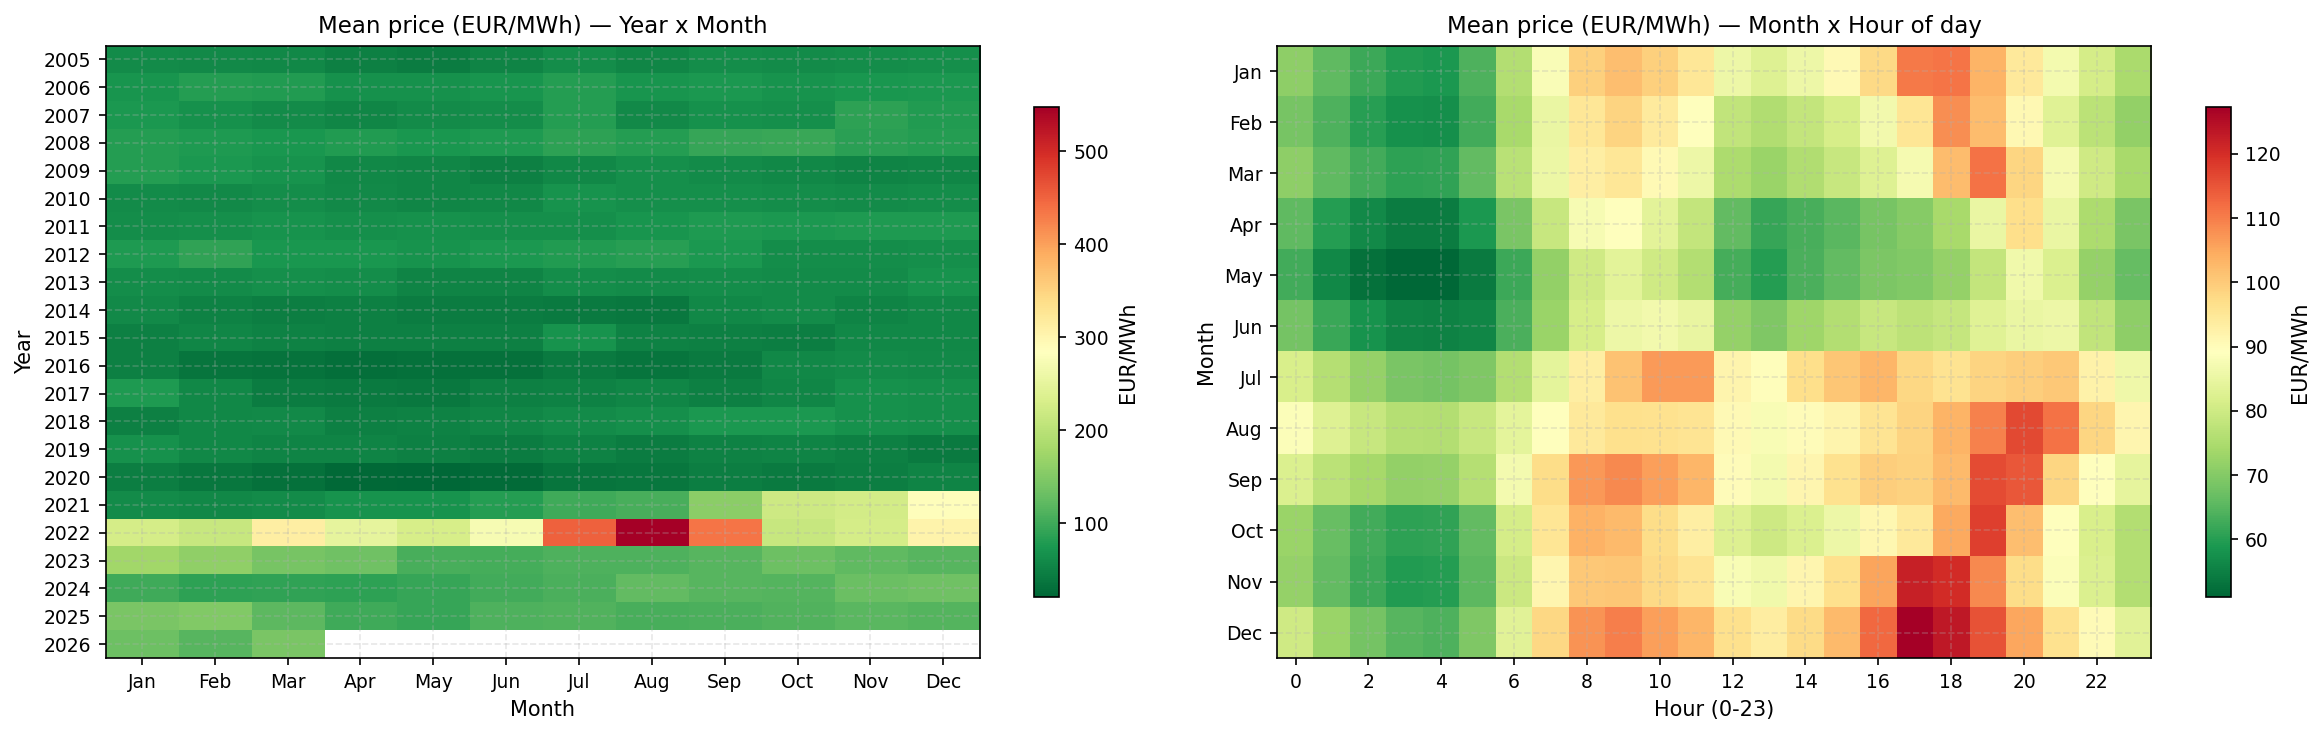

[SAVED] fig_energy_03_seasonality_heatmaps.png / .pdf


In [5]:
pivot_ym = df.pivot_table(values="price_NORD_EURMWh", index="year", columns="month", aggfunc="mean")
pivot_ym.columns = MONTH_LABELS

pivot_mh = df.pivot_table(values="price_NORD_EURMWh", index="month", columns="hour", aggfunc="mean")
pivot_mh.index = MONTH_LABELS

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
im = ax.imshow(pivot_ym.values, aspect="auto", cmap="RdYlGn_r", interpolation="nearest")
ax.set_xticks(range(12)); ax.set_xticklabels(MONTH_LABELS)
ax.set_yticks(range(len(pivot_ym))); ax.set_yticklabels(pivot_ym.index)
ax.set_title("Mean price (EUR/MWh) — Year x Month")
ax.set_xlabel("Month"); ax.set_ylabel("Year")
plt.colorbar(im, ax=ax, label="EUR/MWh", shrink=0.8)

ax = axes[1]
im2 = ax.imshow(pivot_mh.values, aspect="auto", cmap="RdYlGn_r", interpolation="nearest")
ax.set_xticks(range(0, 24, 2)); ax.set_xticklabels(range(0, 24, 2))
ax.set_yticks(range(12)); ax.set_yticklabels(MONTH_LABELS)
ax.set_title("Mean price (EUR/MWh) — Month x Hour of day")
ax.set_xlabel("Hour (0-23)"); ax.set_ylabel("Month")
plt.colorbar(im2, ax=ax, label="EUR/MWh", shrink=0.8)

plt.tight_layout()
plt.show()


> **Takeaway.** The year x month panel shows the 2022 crisis lighting up every
> month that year. The month x hour panel is the direct motivation for this
> thesis: a midday depression that is deepest and widest in the sunniest
> months (Apr-Aug) — solar output pushing the price down exactly when a solar
> plant is generating.

## Intraday Profile

**What to look for:** how the midday dip has deepened over time — the duck
curve emerging as solar penetration grew.

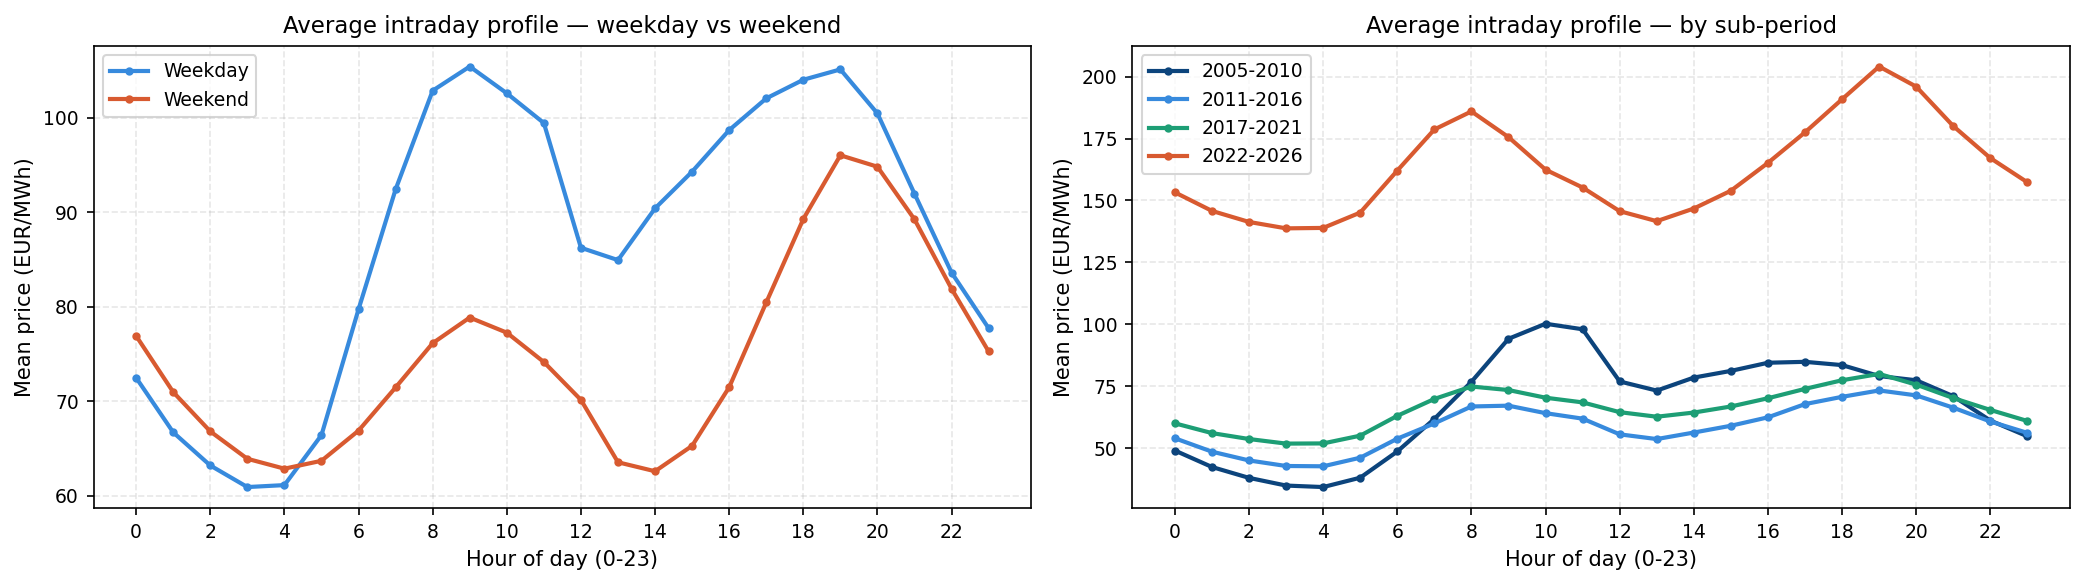

[SAVED] fig_energy_04_intraday_profile.png / .pdf


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
for is_we, label, color in [(False, "Weekday", "#378ADD"), (True, "Weekend", "#D85A30")]:
    profile = df[df["is_weekend"] == is_we].groupby("hour")["price_NORD_EURMWh"].mean()
    ax.plot(profile.index, profile.values, color=color, linewidth=2, label=label, marker="o", markersize=3)
ax.set_title("Average intraday profile — weekday vs weekend")
ax.set_xlabel("Hour of day (0-23)"); ax.set_ylabel("Mean price (EUR/MWh)")
ax.set_xticks(range(0, 24, 2)); ax.legend()

ax = axes[1]
periods = [(2005, 2010, "2005-2010", "#0C447C"), (2011, 2016, "2011-2016", "#378ADD"),
           (2017, 2021, "2017-2021", "#1D9E75"), (2022, 2026, "2022-2026", "#D85A30")]
for y0, y1, label, color in periods:
    sub = df[(df["year"] >= y0) & (df["year"] <= y1)]
    profile = sub.groupby("hour")["price_NORD_EURMWh"].mean()
    ax.plot(profile.index, profile.values, color=color, linewidth=2, label=label, marker="o", markersize=3)
ax.set_title("Average intraday profile — by sub-period")
ax.set_xlabel("Hour of day (0-23)"); ax.set_ylabel("Mean price (EUR/MWh)")
ax.set_xticks(range(0, 24, 2)); ax.legend()

plt.tight_layout()
plt.show()


> **Takeaway.** The midday dip is barely visible in 2005-2010 and pronounced
> by 2022-2026 — the clearest single chart in this notebook for the thesis'
> central claim that rising solar penetration erodes the midday price a solar
> plant depends on.

## Volatility

**What to look for:** whether realised volatility has trended, and whether
the 2021-2022 crisis is also a volatility event, not just a level event. Both
panels use the same daily series, so they are directly comparable.

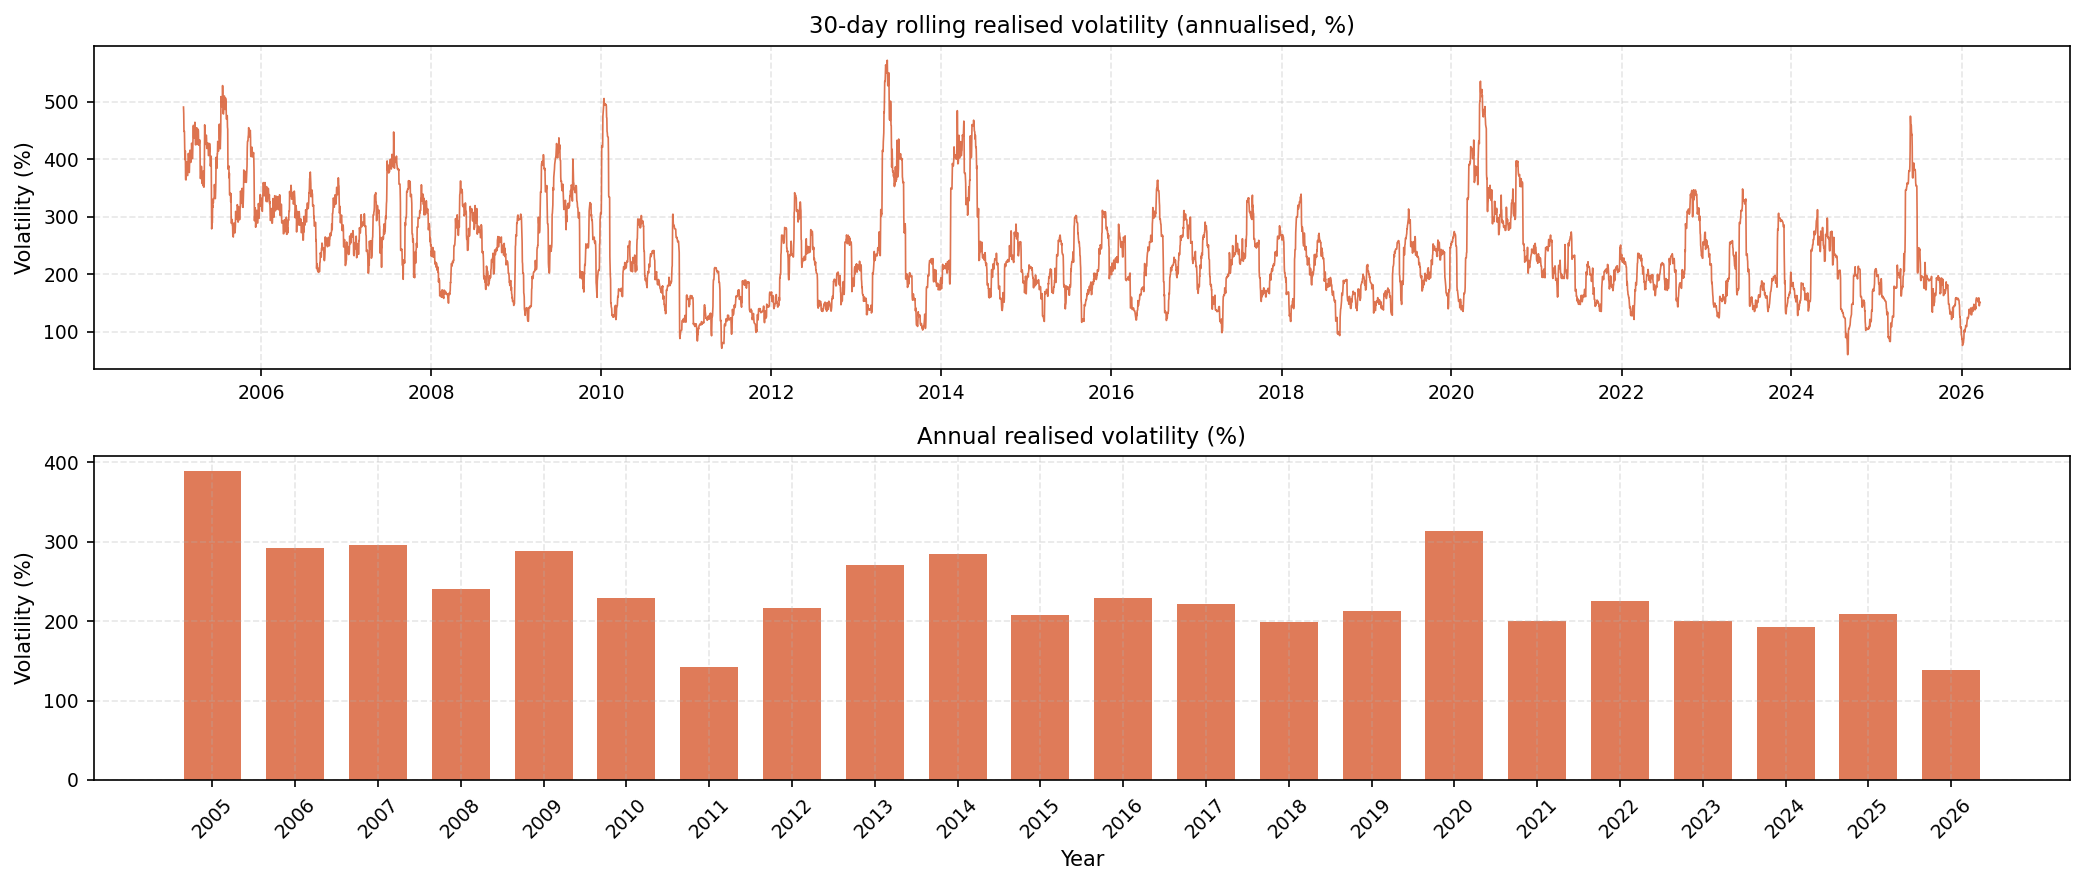

[SAVED] fig_energy_05_volatility.png / .pdf


In [7]:
df_vol = df_daily.set_index("date").copy()
df_vol["log_return"] = np.log(df_vol["price_NORD_EURMWh"] / df_vol["price_NORD_EURMWh"].shift(1))
df_vol["rolling_vol_30d"] = df_vol["log_return"].rolling(30).std() * np.sqrt(252)

ann_vol_yr = df_vol.groupby(df_vol.index.year)["log_return"].std() * np.sqrt(252) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

ax = axes[0]
ax.plot(df_vol.index, df_vol["rolling_vol_30d"] * 100, color="#D85A30", linewidth=0.8, alpha=0.85)
ax.set_title("30-day rolling realised volatility (annualised, %)")
ax.set_ylabel("Volatility (%)")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax = axes[1]
ax.bar(ann_vol_yr.index, ann_vol_yr.values, color="#D85A30", alpha=0.8, width=0.7)
ax.set_title("Annual realised volatility (%)")
ax.set_ylabel("Volatility (%)"); ax.set_xlabel("Year")
ax.set_xticks(ann_vol_yr.index)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


> **Takeaway.** Volatility is low and stable for most of the sample and spikes
> sharply in 2021-2022 alongside the level — the crisis raised both the mean
> and the variance of the price at once.

## Spike Frequency

**What to look for:** whether spikes (price above the 95th percentile within
their own year) cluster by hour, month, or year.

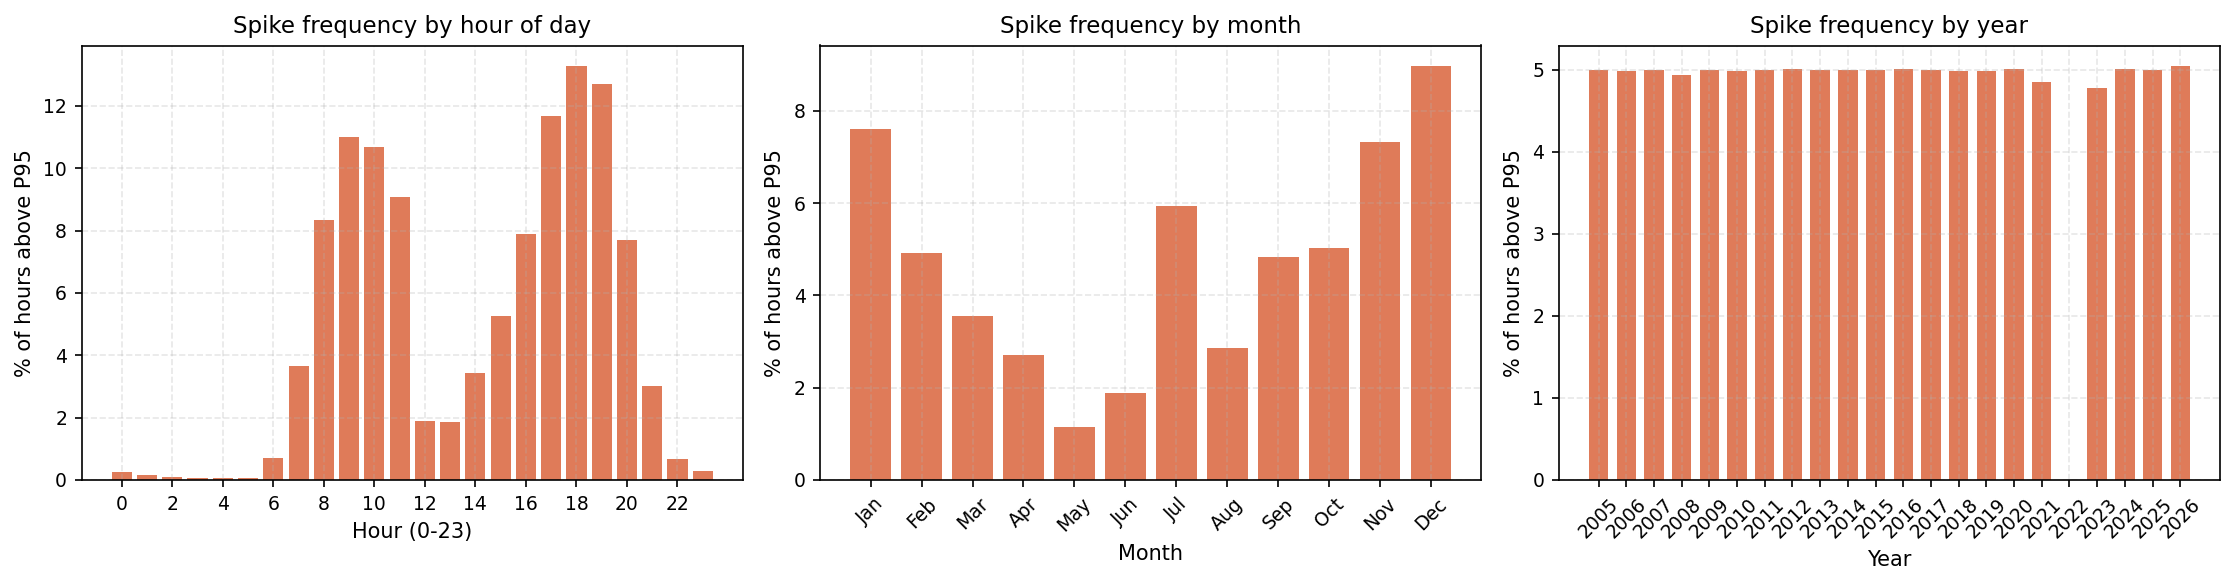

[SAVED] fig_energy_06_spike_frequency.png / .pdf


In [8]:
is_spike = df["price_flag"] == 1   # spike, as flagged in the cleaning notebook

spike_by_hour  = df.groupby("hour")["price_flag"].apply(lambda s: (s == 1).mean()) * 100
spike_by_month = df.groupby("month")["price_flag"].apply(lambda s: (s == 1).mean()) * 100
spike_by_year  = df.groupby("year")["price_flag"].apply(lambda s: (s == 1).mean()) * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.bar(spike_by_hour.index, spike_by_hour.values, color="#D85A30", alpha=0.8)
ax.set_title("Spike frequency by hour of day")
ax.set_xlabel("Hour (0-23)"); ax.set_ylabel("% of hours above P95")
ax.set_xticks(range(0, 24, 2))

ax = axes[1]
ax.bar(range(12), spike_by_month.values, color="#D85A30", alpha=0.8)
ax.set_xticks(range(12)); ax.set_xticklabels(MONTH_LABELS, rotation=45)
ax.set_title("Spike frequency by month")
ax.set_xlabel("Month"); ax.set_ylabel("% of hours above P95")

ax = axes[2]
ax.bar(spike_by_year.index, spike_by_year.values, color="#D85A30", alpha=0.8, width=0.7)
ax.set_title("Spike frequency by year")
ax.set_xlabel("Year"); ax.set_ylabel("% of hours above P95")
ax.set_xticks(spike_by_year.index)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


> **Takeaway.** Spikes cluster in evening peak hours and in winter/summer
> demand-driven months, which is expected; the by-year panel shows spikes are
> not a single-year artifact of the P95-within-year definition but recur most
> years.

## Intraday Spread

**What to look for:** whether the gap between the day's highest and lowest
hourly price has widened, consistent with a deepening midday dip.

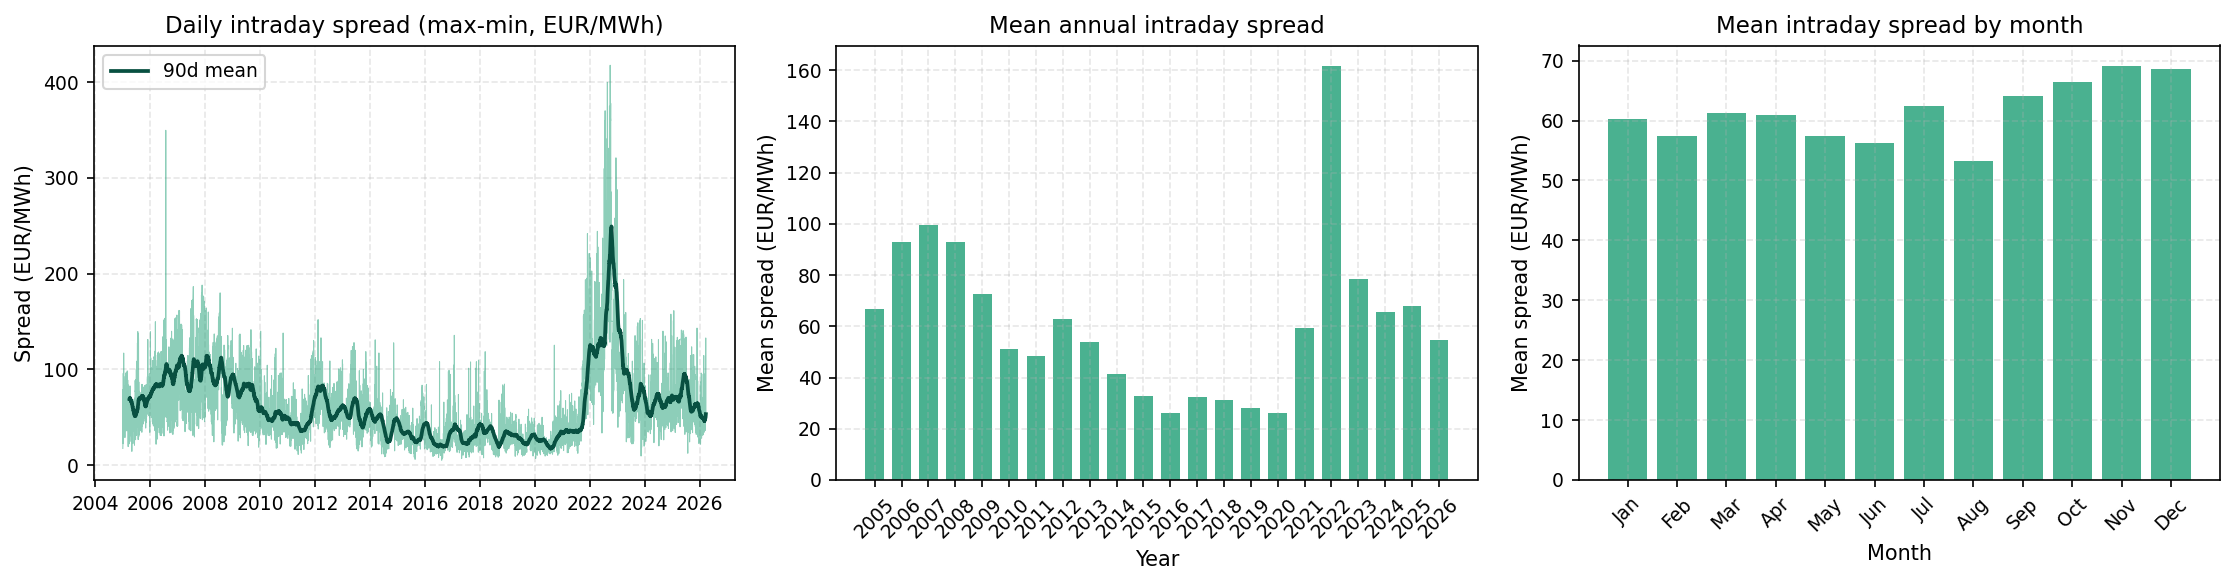

[SAVED] fig_energy_07_intraday_spread.png / .pdf


In [9]:
df_spread = df.groupby("date")["price_NORD_EURMWh"].agg(daily_max="max", daily_min="min").reset_index()
df_spread["daily_spread"] = df_spread["daily_max"] - df_spread["daily_min"]
df_spread["year"]  = pd.to_datetime(df_spread["date"]).dt.year
df_spread["month"] = pd.to_datetime(df_spread["date"]).dt.month

spread_annual  = df_spread.groupby("year")["daily_spread"].mean()
spread_monthly = df_spread.groupby("month")["daily_spread"].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(df_spread["date"], df_spread["daily_spread"], color="#1D9E75", linewidth=0.5, alpha=0.5)
roll_spread = df_spread.set_index("date")["daily_spread"].rolling(90).mean()
ax.plot(roll_spread.index, roll_spread.values, color="#085041", linewidth=1.8, label="90d mean")
ax.set_title("Daily intraday spread (max-min, EUR/MWh)")
ax.set_ylabel("Spread (EUR/MWh)")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()

ax = axes[1]
ax.bar(spread_annual.index, spread_annual.values, color="#1D9E75", alpha=0.8, width=0.7)
ax.set_title("Mean annual intraday spread")
ax.set_xlabel("Year"); ax.set_ylabel("Mean spread (EUR/MWh)")
ax.set_xticks(spread_annual.index)
ax.tick_params(axis="x", rotation=45)

ax = axes[2]
ax.bar(range(12), spread_monthly.values, color="#1D9E75", alpha=0.8)
ax.set_xticks(range(12)); ax.set_xticklabels(MONTH_LABELS, rotation=45)
ax.set_title("Mean intraday spread by month")
ax.set_xlabel("Month"); ax.set_ylabel("Mean spread (EUR/MWh)")

plt.tight_layout()
plt.show()


> **Takeaway.** The spread trends upward over the sample and peaks in summer
> months — the same solar-driven midday dip widening the daily range, on top
> of the 2021-2022 crisis spike visible in the time series panel.

## Zonal Spread (NORD vs PUN)

**What to look for:** whether the NORD zone systematically prices differently
from the national reference, and when.

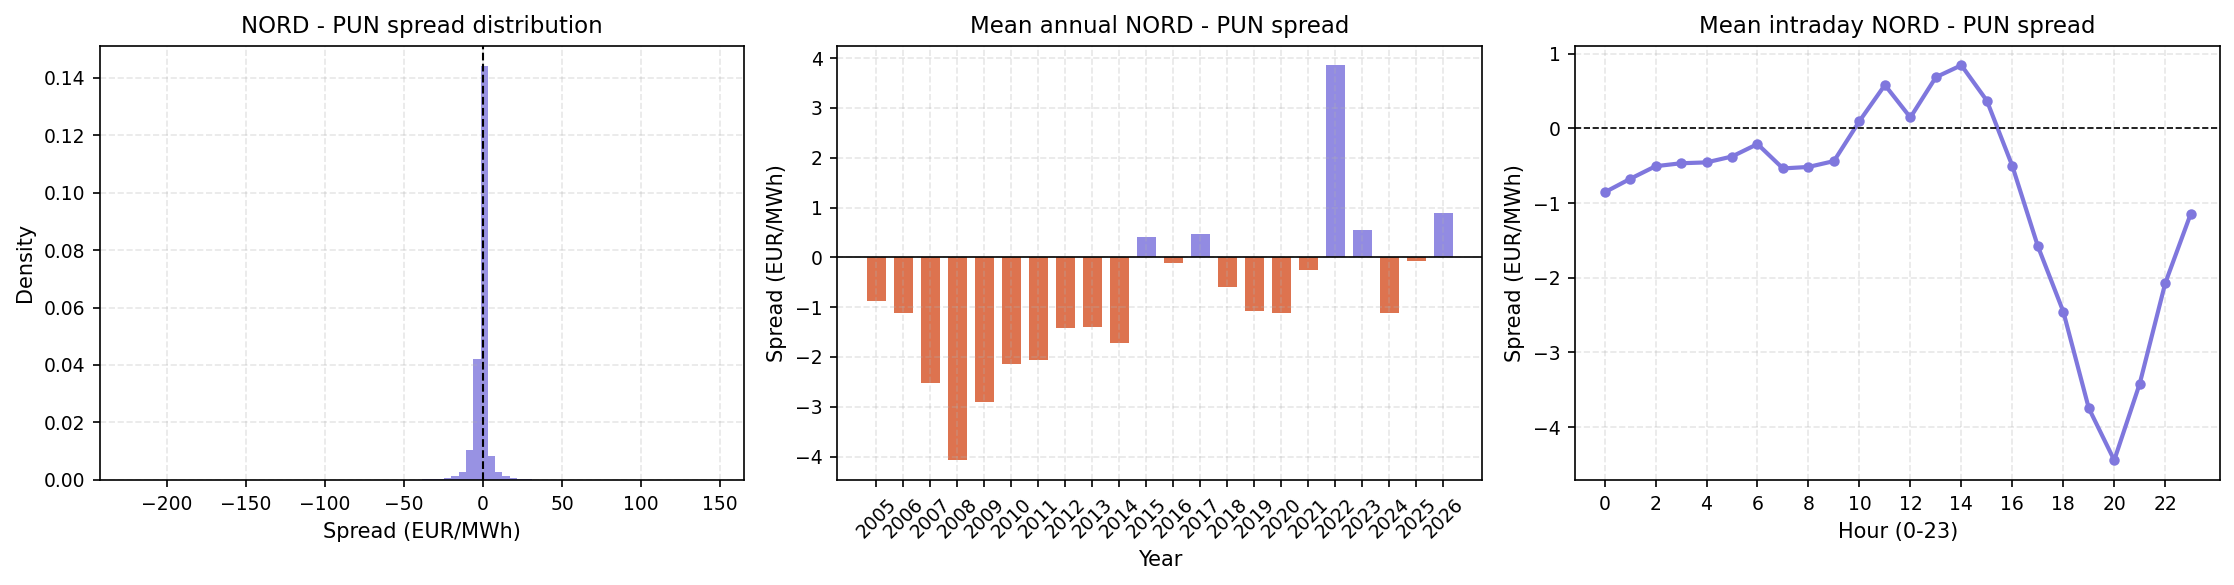

[SAVED] fig_energy_08_zonal_spread.png / .pdf


In [10]:
df["zonal_spread"] = df["price_NORD_EURMWh"] - df["price_PUN_EURMWh"]

zonal_annual = df.groupby("year")["zonal_spread"].mean()
zonal_hourly = df.groupby("hour")["zonal_spread"].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.hist(df["zonal_spread"].dropna(), bins=80, color="#7F77DD", alpha=0.8, edgecolor="none", density=True)
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("NORD - PUN spread distribution")
ax.set_xlabel("Spread (EUR/MWh)"); ax.set_ylabel("Density")

ax = axes[1]
colors_z = ["#7F77DD" if v >= 0 else "#D85A30" for v in zonal_annual.values]
ax.bar(zonal_annual.index, zonal_annual.values, color=colors_z, alpha=0.85, width=0.7)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Mean annual NORD - PUN spread")
ax.set_xlabel("Year"); ax.set_ylabel("Spread (EUR/MWh)")
ax.set_xticks(zonal_annual.index)
ax.tick_params(axis="x", rotation=45)

ax = axes[2]
ax.plot(zonal_hourly.index, zonal_hourly.values, color="#7F77DD", linewidth=2, marker="o", markersize=4)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Mean intraday NORD - PUN spread")
ax.set_xlabel("Hour (0-23)"); ax.set_ylabel("Spread (EUR/MWh)")
ax.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()


> **Takeaway.** NORD prices sit close to the national PUN on average, with a
> small positive spread in most years — the two track closely enough that PUN
> is a reasonable secondary reference, but not identical, justifying the
> zonal (NORD) price as the primary series for a plant located in that zone.

## Annual Summary Table

In [11]:
summary = df.groupby("year")["price_NORD_EURMWh"].agg(
    Mean="mean", Std="std", Min="min",
    P10=lambda x: x.quantile(0.10), P25=lambda x: x.quantile(0.25),
    Median="median", P75=lambda x: x.quantile(0.75), P90=lambda x: x.quantile(0.90),
    Max="max", Spikes=lambda x: (x > x.quantile(0.95)).sum(),
).round(2)

summary_path = RESULTS_DIR / "GME_NORD_annual_summary.csv"
summary.to_csv(summary_path)
print(f"[SAVED] {summary_path}")
summary

[SAVED] C:\Users\LucasMonero\OneDrive - EloGroup\Documentos\data projects\Master Thesis\Project\Data\Results\GME_NORD_annual_summary.csv


,Mean,Std,Min,P10,P25,Median,P75,P90,Max,Spikes
year,,,,,,,,,,
2005,57.69,27.73,10.00,25.79,35.22,50.60,77.69,100.11,170.61,438
2006,73.63,33.71,3.00,39.50,49.69,64.49,89.95,120.18,400.00,436
2007,68.47,35.99,15.00,27.97,45.04,61.63,84.89,113.29,239.57,438
2008,82.92,31.59,20.50,41.90,62.50,79.91,100.00,125.16,209.98,433
2009,60.82,25.81,9.00,28.00,45.00,56.56,76.00,95.00,169.01,438
2010,61.98,17.56,10.00,41.99,51.90,61.70,69.90,80.05,189.01,437
2011,70.18,15.67,10.00,51.10,61.54,69.31,78.55,87.72,165.07,438
2012,74.05,21.53,13.00,47.03,63.00,73.50,84.69,95.29,224.00,440
2013,61.58,17.38,0.00,38.00,54.98,63.00,70.01,79.00,150.04,438


## Conclusion & Handoff

- The NORD price series shows a clear structural break in 2021-2022 (level
  and volatility), a fat-tailed distribution, and a midday price dip that
  deepens over the sample — the visual case for solar cannibalisation this
  thesis models.
- Eight figures and one annual summary table are saved to `Data/Results/` for
  direct use in the thesis write-up.

**This notebook is terminal** — nothing downstream reads its outputs; it is
exploratory context for the capture-rate model in
`Code/Modelling/Capture Price Model.ipynb`, which reads
`Data/Cleaned/df_energy_cleaned.parquet` directly.